# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [ ]:
df.head()

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Load the dataset from your exact local file path
file_path = r"D:\Fusemachines_Fellowship\Week4\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

# Display dataset shape and basic row/column metrics
print("--- Dataset Structural Shape ---")
print(df.shape)

print("\n--- Data Types and Structural Info ---")
print(df.info())

--- Dataset Structural Shape ---
(7043, 21)

--- Data Types and Structural Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract        

In [7]:
print("--- Summary Statistics ---")
print(df.describe(include='all'))

# Inspect the known issue where TotalCharges contains whitespace strings (' ')
print("\n--- Rows containing whitespace strings in TotalCharges ---")
whitespace_rows = df[df['TotalCharges'] == ' ']
print(f"Number of rows with missing whitespace values: {len(whitespace_rows)}")
print(whitespace_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

--- Summary Statistics ---
        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     7590-VHVEG   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecu

In [8]:
print("--- Checking for standard missing (NaN) values per column ---")
print(df.isnull().sum())

print("\n--- Value Counts of Target Variable (Churn) ---")
print(df['Churn'].value_counts())

--- Checking for standard missing (NaN) values per column ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- Value Counts of Target Variable (Churn) ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): all customer features except `customerID` and `Churn`
- y (target variable): `Churn` encoded as 0/1
- Probability distribution of y: Bernoulli
- Natural loss function: binary cross-entropy / log loss
- Hypothesis class: linear models for classification
- Assumption 1: current customers follow a similar distribution to the training sample
- Assumption 2: the encoded features are sufficient to explain most churn signal
- Assumption 3: labels and preprocessing are correct after fixing missing `TotalCharges`
- Sources of uncertainty: sampling bias, label noise, missing data, drift, and unobserved non-linear effects

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [18]:
# Convert TotalCharges to numeric, coercing whitespace strings to NaN values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')

# Since missing values occur exclusively where tenure is 0, fill with 0.0 safely
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Map the target variable to binary integers (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Data corrections and target encoding completed successfully.")

Data corrections and target encoding completed successfully.


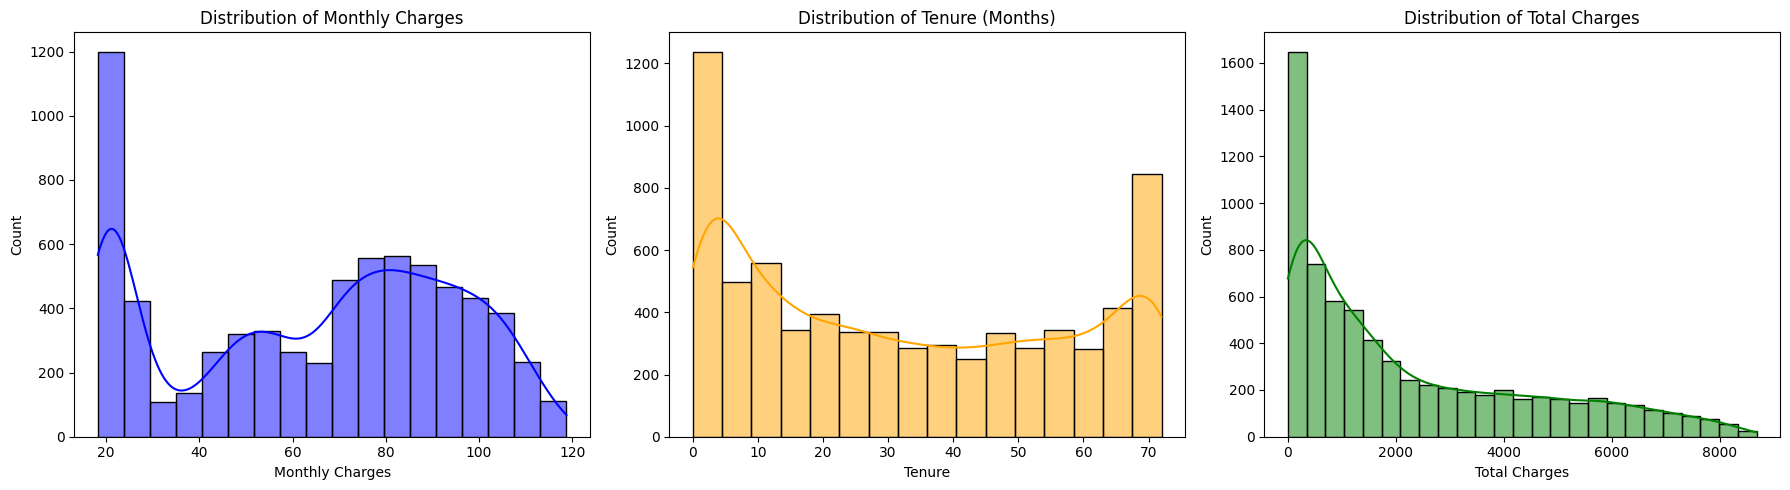

In [10]:
# Profile distributions for continuous variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Monthly Charges')
axes[0].set_xlabel('Monthly Charges')

sns.histplot(df['tenure'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Tenure (Months)')
axes[1].set_xlabel('Tenure')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Total Charges')
axes[2].set_xlabel('Total Charges')

plt.tight_layout()
plt.show()

In [11]:
# Confirm structural shifts have run correctly without losing rows
print(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].describe())

            tenure  MonthlyCharges  TotalCharges        Churn
count  7043.000000     7043.000000   7043.000000  7043.000000
mean     32.371149       64.761692   2279.734304     0.265370
std      24.559481       30.090047   2266.794470     0.441561
min       0.000000       18.250000      0.000000     0.000000
25%       9.000000       35.500000    398.550000     0.000000
50%      29.000000       70.350000   1394.550000     0.000000
75%      55.000000       89.850000   3786.600000     1.000000
max      72.000000      118.750000   8684.800000     1.000000


---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [13]:
pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

# Split target from features for baseline analysis
X_base = df.drop(columns=['customerID', 'Churn'])
y_base = df['Churn']

# Instantiate a baseline model that always predicts the majority class
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_base, y_base)
baseline_preds = dummy_clf.predict(X_base)

baseline_accuracy = accuracy_score(y_base, baseline_preds)
baseline_recall = recall_score(y_base, baseline_preds)
baseline_f1 = f1_score(y_base, baseline_preds)

print(f'Baseline accuracy: {baseline_accuracy:.4f}')
print(f'Baseline recall: {baseline_recall:.4f}')
print(f'Baseline F1: {baseline_f1:.4f}')
print('\nClassification report:')
print(classification_report(y_base, baseline_preds, target_names=['No Churn', 'Churn']))

Baseline accuracy: 0.7346
Baseline recall: 0.0000
Baseline F1: 0.0000

Classification report:
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      5174
       Churn       0.00      0.00      0.00      1869

    accuracy                           0.73      7043
   macro avg       0.37      0.50      0.42      7043
weighted avg       0.54      0.73      0.62      7043



c:\Users\risha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\risha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\risha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
class_counts = df['Churn'].value_counts()
class_props = df['Churn'].value_counts(normalize=True)

print('--- Churn Class Distribution ---')
print(class_counts)
print('\n--- Churn Class Proportions ---')
print(class_props)
print(f"\nMajority-class accuracy baseline: {class_props.max():.4f}")

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

No. That score is just the majority-class baseline, and it catches none of the churners. The first question is: what is recall or PR-AUC on the churn class, and how many churners do we actually identify?

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare features and target
X_all = pd.get_dummies(df.drop(columns=['customerID', 'Churn']), drop_first=True)
y_all = df['Churn'].astype(int)

# Stratified 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=42,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print('Split sizes:')
print(f'Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}')
print('\nClass balance in each split:')
print('Train:', y_train.value_counts(normalize=True).to_dict())
print('Validation:', y_val.value_counts(normalize=True).to_dict())
print('Test:', y_test.value_counts(normalize=True).to_dict())

Split sizes:
Train: (4930, 30), Validation: (1056, 30), Test: (1057, 30)

Class balance in each split:
Train: {0: 0.734685598377282, 1: 0.2653144016227181}
Validation: {0: 0.7348484848484849, 1: 0.26515151515151514}
Test: {0: 0.7341532639545885, 1: 0.26584673604541154}


In [ ]:
print('Training feature count:', X_train.shape[1])
print('First 10 feature names:')
print(list(X_train.columns[:10]))
print('\nScaled arrays ready:')
print(X_train_s.shape, X_val_s.shape, X_test_s.shape)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss

# Shared helper functions for classifier evaluation

def _get_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        return scores
    return model.predict(X)


def evaluate_classifier(model, X, y):
    preds = model.predict(X)
    scores = _get_scores(model, X)
    prob_scores = scores if scores.ndim == 1 else scores[:, 1]

    metrics = {
        'accuracy': accuracy_score(y, preds),
        'precision': precision_score(y, preds, zero_division=0),
        'recall': recall_score(y, preds, zero_division=0),
        'f1': f1_score(y, preds, zero_division=0),
        'roc_auc': roc_auc_score(y, scores),
        'pr_auc': average_precision_score(y, scores),
    }

    if hasattr(model, 'predict_proba'):
        metrics['log_loss'] = log_loss(y, model.predict_proba(X))
    else:
        metrics['log_loss'] = np.nan

    return metrics, preds, scores

print('Classifier evaluation helpers defined.')

Classifier evaluation helpers defined.


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [20]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=1000, random_state=42)
start_time = time.time()
lr_clf.fit(X_train_s, y_train)
lr_train_time = time.time() - start_time
print(f'Logistic Regression training time: {lr_train_time:.4f} seconds')

Logistic Regression training time: 0.0262 seconds


In [21]:
from sklearn.linear_model import RidgeClassifier

ridge_clf = RidgeClassifier()
start_time = time.time()
ridge_clf.fit(X_train_s, y_train)
ridge_train_time = time.time() - start_time
print(f'Ridge Classifier training time: {ridge_train_time:.4f} seconds')

Ridge Classifier training time: 0.0118 seconds


In [22]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
start_time = time.time()
sgd_clf.fit(X_train_s, y_train)
sgd_train_time = time.time() - start_time
print(f'SGD Classifier training time: {sgd_train_time:.4f} seconds')

SGD Classifier training time: 0.0328 seconds


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [25]:
classification_models = {
    'Logistic Regression': lr_clf,
    'Ridge Classifier': ridge_clf,
    'SGD Classifier': sgd_clf,
}

classification_scores = {}
classification_predictions = {}

for name, model in classification_models.items():
    metrics, preds, scores = evaluate_classifier(model, X_val_s, y_val)
    metrics['train_time'] = {
        'Logistic Regression': lr_train_time,
        'Ridge Classifier': ridge_train_time,
        'SGD Classifier': sgd_train_time,
    }[name]
    classification_scores[name] = metrics
    classification_predictions[name] = {
        'preds': preds,
        'scores': scores,
    }

comparison_df = pd.DataFrame(classification_scores).T.sort_values('pr_auc', ascending=False)
comparison_df

,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,train_time
Logistic Regression,0.807765,0.649805,0.596429,0.621974,0.845441,0.630831,0.418769,0.026242
Ridge Classifier,0.803030,0.653846,0.546429,0.595331,0.837742,0.623839,NaN,0.011815
SGD Classifier,0.750947,0.529412,0.546429,0.537786,0.794691,0.578301,0.481962,0.032841


In [26]:
best_classifier_name = comparison_df.index[0]
best_classifier = classification_models[best_classifier_name]
best_classifier_metrics = comparison_df.loc[best_classifier_name]

print(f'Best classifier by PR-AUC: {best_classifier_name}')
print('\nValidation metrics for the chosen model:')
print(best_classifier_metrics)

comparison_df

Best classifier by PR-AUC: Logistic Regression

Validation metrics for the chosen model:
accuracy      0.807765
precision     0.649805
recall        0.596429
f1            0.621974
roc_auc       0.845441
pr_auc        0.630831
log_loss      0.418769
train_time    0.026242
Name: Logistic Regression, dtype: float64


,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,train_time
Logistic Regression,0.807765,0.649805,0.596429,0.621974,0.845441,0.630831,0.418769,0.026242
Ridge Classifier,0.803030,0.653846,0.546429,0.595331,0.837742,0.623839,NaN,0.011815
SGD Classifier,0.750947,0.529412,0.546429,0.537786,0.794691,0.578301,0.481962,0.032841


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


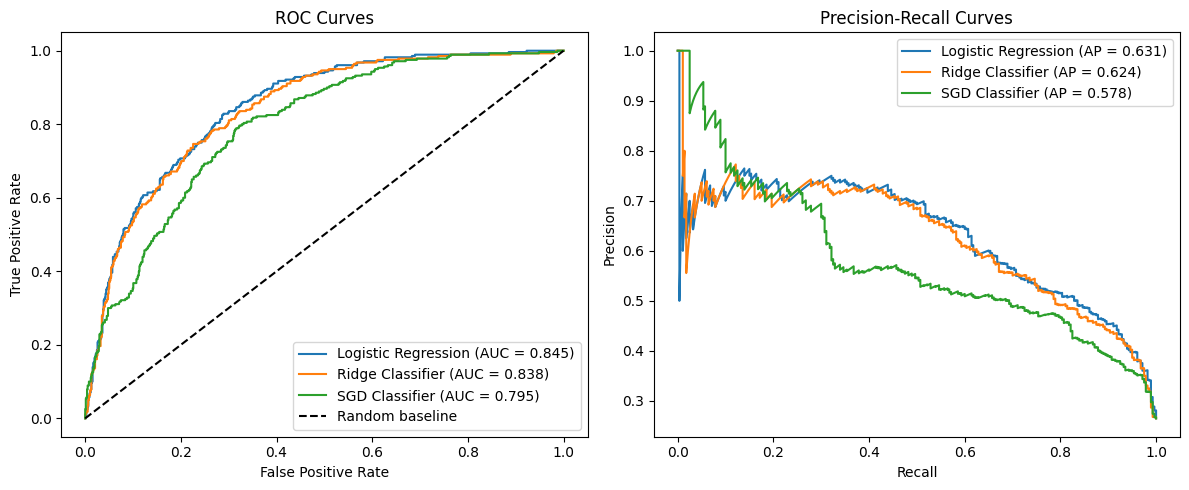

In [27]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name, model in classification_models.items():
    scores = classification_predictions[name]['scores']
    fpr, tpr, _ = roc_curve(y_val, scores)
    precision, recall, _ = precision_recall_curve(y_val, scores)

    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_val, scores):.3f})')
    ax2.plot(recall, precision, label=f'{name} (AP = {average_precision_score(y_val, scores):.3f})')

ax1.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax1.set_title('ROC Curves')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

ax2.set_title('Precision-Recall Curves')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()

plt.tight_layout()
plt.show()

In [28]:
best_scores = classification_predictions[best_classifier_name]['scores']

if hasattr(best_classifier, 'predict_proba'):
    validation_probabilities = best_classifier.predict_proba(X_val_s)[:, 1]
else:
    validation_probabilities = best_scores

sorted_indices = np.argsort(validation_probabilities)[::-1]
threshold_200 = validation_probabilities[sorted_indices[199]]

preds_top_200 = (validation_probabilities >= threshold_200).astype(int)
preds_default = (validation_probabilities >= 0.5).astype(int)

top_200_metrics = {
    'precision': precision_score(y_val, preds_top_200, zero_division=0),
    'recall': recall_score(y_val, preds_top_200, zero_division=0),
    'f1': f1_score(y_val, preds_top_200, zero_division=0),
}
default_metrics = {
    'precision': precision_score(y_val, preds_default, zero_division=0),
    'recall': recall_score(y_val, preds_default, zero_division=0),
    'f1': f1_score(y_val, preds_default, zero_division=0),
}

print(f'Best model: {best_classifier_name}')
print(f'200-customer threshold: {threshold_200:.6f}')
print('\nTop-200 metrics:')
print(top_200_metrics)
print('\nDefault 0.5 metrics:')
print(default_metrics)

Best model: Logistic Regression
200-customer threshold: 0.562719

Top-200 metrics:
{'precision': 0.695, 'recall': 0.49642857142857144, 'f1': 0.5791666666666667}

Default 0.5 metrics:
{'precision': 0.6498054474708171, 'recall': 0.5964285714285714, 'f1': 0.6219739292364991}


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [ ]:
# your code here

In [ ]:
# your code here

---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [ ]:

def evaluate_regressor(model, X, y):
    preds = model.predict(X)
    metrics = {
        'mae': mean_absolute_error(y, preds),
        'rmse': mean_squared_error(y, preds, squared=False),
        'r2': r2_score(y, preds),
    }
    return metrics

regression_results = {}
for name, model in regression_models.items():
    regression_results[name] = evaluate_regressor(model, X_reg_val_s, y_reg_val)

reg_comparison_df = pd.DataFrame(regression_results).T.sort_values('r2', ascending=False)
reg_comparison_df


---

## 4.3 Residual Analysis

### Task:
Plot the residuals (true values vs. predicted values) for your best regression model.

### Questions:
- Is there a pattern in the residuals?
- What does the pattern (or lack thereof) tell you about your model's fit?
- Are there any major outliers?

### Hint:
- Residuals = `y_true - y_pred`
- A good fit shows residuals randomly scattered around zero
- A pattern (like a curve or a funnel shape) indicates that the model is missing something (e.g., non-linearity, heteroscedasticity)

---


In [29]:
if hasattr(best_classifier, 'coef_'):
    coefficients = pd.Series(best_classifier.coef_[0], index=X_train.columns)
else:
    coefficients = pd.Series(lr_clf.coef_[0], index=X_train.columns)

print('Top 10 features by absolute coefficient magnitude:')
print(coefficients.abs().nlargest(10))

Top 10 features by absolute coefficient magnitude:
tenure                         1.324185
MonthlyCharges                 0.706191
TotalCharges                   0.644252
InternetService_Fiber optic    0.626530
Contract_Two year              0.568400
Contract_One year              0.297690
StreamingMovies_Yes            0.237066
PaperlessBilling_Yes           0.201317
MultipleLines_Yes              0.197117
StreamingTV_Yes                0.191661
dtype: float64


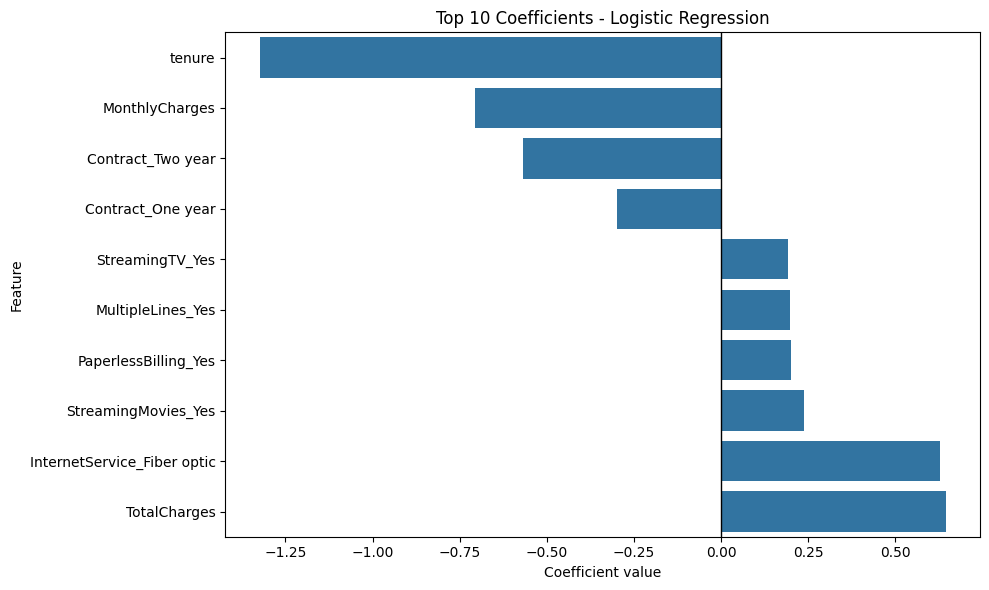

In [30]:
feature_rank = coefficients.abs().nlargest(10).index
ordered_coefficients = coefficients.loc[feature_rank].sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=ordered_coefficients.values, y=ordered_coefficients.index, orient='h')
plt.axvline(0, color='black', linewidth=1)
plt.title(f'Top 10 Coefficients - {best_classifier_name}')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

Deploy Logistic Regression. It has the best validation PR-AUC and ROC-AUC, the best F1 among the classifiers, and calibrated probabilities for threshold tuning. Ridge is close but lacks probability output, and SGD is less stable and weaker here.

SGD does not exactly converge to the same coefficients because it uses noisy gradient updates, a finite number of iterations, and a different optimization path; with enough tuning it can approximate LR, but it is not guaranteed to match it exactly.

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression

In [ ]:
sgd_compare_clf = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

start_time = time.time()
lr_compare_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_compare_clf.fit(X_train_s, y_train)
lr_compare_time = time.time() - start_time

start_time = time.time()
sgd_compare_clf.fit(X_train_s, y_train)
sgd_compare_time = time.time() - start_time

print(f'Logistic Regression time: {lr_compare_time:.4f} seconds')
print(f'SGD Classifier time: {sgd_compare_time:.4f} seconds')

In [ ]:
lr_compare_scores = _get_scores(lr_compare_clf, X_val_s)
sgd_compare_scores = _get_scores(sgd_compare_clf, X_val_s)

print('Logistic Regression vs SGDClassifier')
print(f'LR ROC-AUC: {roc_auc_score(y_val, lr_compare_scores):.4f}')
print(f'SGD ROC-AUC: {roc_auc_score(y_val, sgd_compare_scores):.4f}')
print(f'Predictions identical: {np.array_equal(lr_compare_clf.predict(X_val_s), sgd_compare_clf.predict(X_val_s))}')
print(f'Coefficients approximately close: {np.allclose(lr_compare_clf.coef_, sgd_compare_clf.coef_, atol=0.15)}')

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression target: customer tenure in months
# Drop the target column from the feature set to avoid leakage.
y_reg = df['tenure'].astype(float)
X_reg_all = pd.get_dummies(df.drop(columns=['customerID', 'Churn', 'tenure']), drop_first=True)

X_reg_train = X_reg_all.loc[X_train.index]
X_reg_val = X_reg_all.loc[X_val.index]
X_reg_test = X_reg_all.loc[X_test.index]

y_reg_train = y_reg.loc[X_train.index]
y_reg_val = y_reg.loc[X_val.index]
y_reg_test = y_reg.loc[X_test.index]

scaler_reg = StandardScaler()
X_reg_train_s = scaler_reg.fit_transform(X_reg_train)
X_reg_val_s = scaler_reg.transform(X_reg_val)
X_reg_test_s = scaler_reg.transform(X_reg_test)

print(y_reg.describe())

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


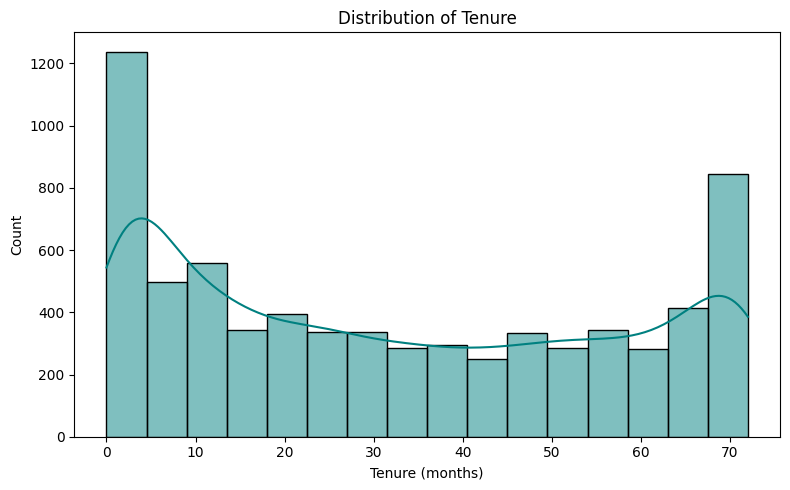

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(y_reg, kde=True, color='teal')
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [33]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
start_time = time.time()
lr_reg.fit(X_reg_train_s, y_reg_train)
lr_reg_train_time = time.time() - start_time
print(f'Linear Regression training time: {lr_reg_train_time:.4f} seconds')

Linear Regression training time: 0.0062 seconds


In [34]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1.0)
start_time = time.time()
ridge_reg.fit(X_reg_train_s, y_reg_train)
ridge_reg_train_time = time.time() - start_time
print(f'Ridge Regression training time: {ridge_reg_train_time:.4f} seconds')

Ridge Regression training time: 0.0027 seconds


In [36]:
from sklearn.linear_model import Lasso, ElasticNet

lasso_reg = Lasso(alpha=0.01, max_iter=5000, random_state=42)
start_time = time.time()
lasso_reg.fit(X_reg_train_s, y_reg_train)
lasso_reg_train_time = time.time() - start_time
print(f'Lasso Regression training time: {lasso_reg_train_time:.4f} seconds')

regression_models = {
    'LinearRegression': lr_reg,
    'Ridge': ridge_reg,
    'Lasso': lasso_reg,
}

regression_results = {}
for name, model in regression_models.items():
    predictions = model.predict(X_reg_val_s)
    regression_results[name] = {
        'mae': mean_absolute_error(y_reg_val, predictions),
        'rmse': np.sqrt(mean_squared_error(y_reg_val, predictions)),
        'r2': r2_score(y_reg_val, predictions),
    }

regression_comparison_df = pd.DataFrame(regression_results).T.sort_values('r2', ascending=False)
best_regressor_name = regression_comparison_df.index[0]
best_regressor = regression_models[best_regressor_name]
regression_comparison_df

Lasso Regression training time: 0.0559 seconds


,mae,rmse,r2
LinearRegression,6.737948,8.826506,0.867303
Lasso,6.730795,8.826752,0.867295
Ridge,6.738676,8.827823,0.867263


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


In [37]:
y_reg_val_pred = best_regressor.predict(X_reg_val_s)
residuals = y_reg_val_pred - y_reg_val

print(f'Best regression model: {best_regressor_name}')
print(f'Residual mean: {residuals.mean():.4f}')
print(f'Residual std: {residuals.std():.4f}')

Best regression model: LinearRegression
Residual mean: -0.3135
Residual std: 8.8251


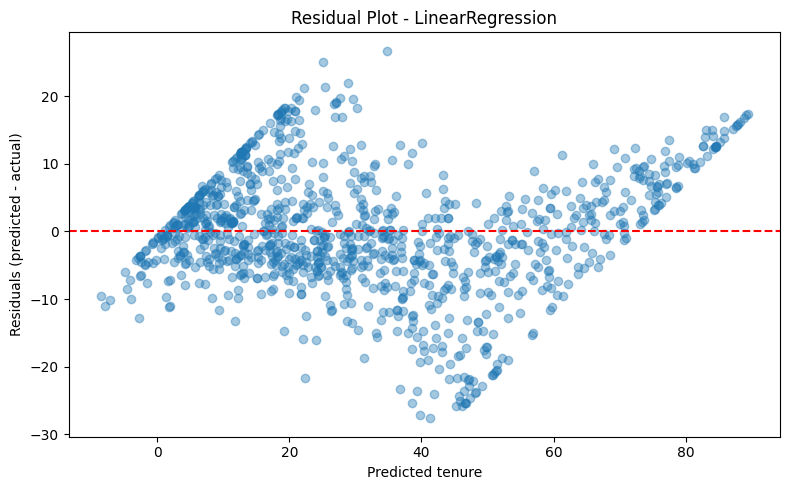

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(y_reg_val_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title(f'Residual Plot - {best_regressor_name}')
plt.xlabel('Predicted tenure')
plt.ylabel('Residuals (predicted - actual)')
plt.tight_layout()
plt.show()

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [39]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

lasso_path_rows = []
ridge_path_rows = []
elastic_path_rows = []

for alpha in alphas:
    ridge_tmp = Ridge(alpha=alpha)
    ridge_tmp.fit(X_reg_train_s, y_reg_train)
    ridge_path_rows.append(pd.Series(ridge_tmp.coef_, index=X_reg_train.columns, name=alpha))

    lasso_tmp = Lasso(alpha=alpha, max_iter=5000, random_state=42)
    lasso_tmp.fit(X_reg_train_s, y_reg_train)
    lasso_path_rows.append(pd.Series(lasso_tmp.coef_, index=X_reg_train.columns, name=alpha))

    elastic_tmp = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000, random_state=42)
    elastic_tmp.fit(X_reg_train_s, y_reg_train)
    elastic_path_rows.append(pd.Series(elastic_tmp.coef_, index=X_reg_train.columns, name=alpha))

ridge_path_df = pd.DataFrame(ridge_path_rows)
lasso_path_df = pd.DataFrame(lasso_path_rows)
elastic_path_df = pd.DataFrame(elastic_path_rows)

print('Coefficient paths computed for Ridge, Lasso, and Elastic Net.')

Coefficient paths computed for Ridge, Lasso, and Elastic Net.


c:\Users\risha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.368e+02, tolerance: 2.994e+02
  model = cd_fast.enet_coordinate_descent(


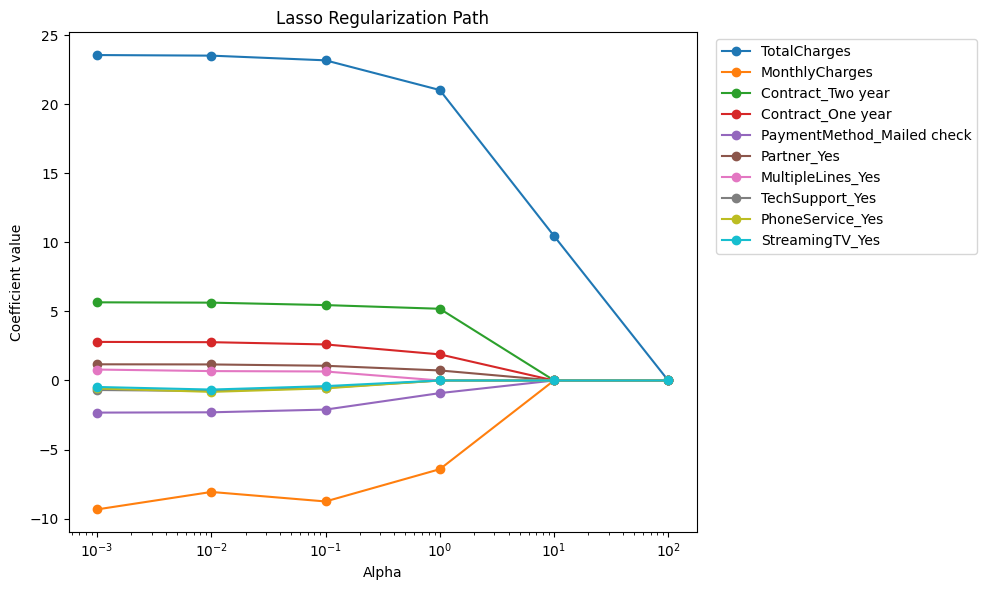

In [40]:
top_path_features = lasso_path_df.abs().mean().nlargest(10).index

plt.figure(figsize=(10, 6))
for feature in top_path_features:
    plt.plot(alphas, lasso_path_df[feature], marker='o', label=feature)

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient value')
plt.title('Lasso Regularization Path')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
high_alpha = 100
ridge_high = ridge_path_df.loc[high_alpha]
lasso_high = lasso_path_df.loc[high_alpha]
elastic_high = elastic_path_df.loc[high_alpha]

print('Features surviving at high Lasso regularization:')
print(lasso_high[lasso_high != 0].sort_values(key=np.abs, ascending=False).head(10))
print('\nRidge coefficients remain non-zero but shrink smoothly.')
print('\nElastic Net keeps a mix of shrinkage and sparsity.')

Features surviving at high Lasso regularization:
Series([], Name: 100.0, dtype: float64)

Ridge coefficients remain non-zero but shrink smoothly.

Elastic Net keeps a mix of shrinkage and sparsity.


---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [42]:
regression_val_predictions = np.maximum(best_regressor.predict(X_reg_val_s), 0)
clv = df.loc[X_val.index, 'MonthlyCharges'].to_numpy() * regression_val_predictions

print(f'Mean CLV: {clv.mean():.2f}')
print(f'Median CLV: {np.median(clv):.2f}')

Mean CLV: 2222.63
Median CLV: 1123.10


count     1056.000000
mean      2222.634165
std       2395.121041
min          0.000000
25%        540.615776
50%       1123.100724
75%       3219.196037
max      10283.546784
Name: CLV, dtype: float64


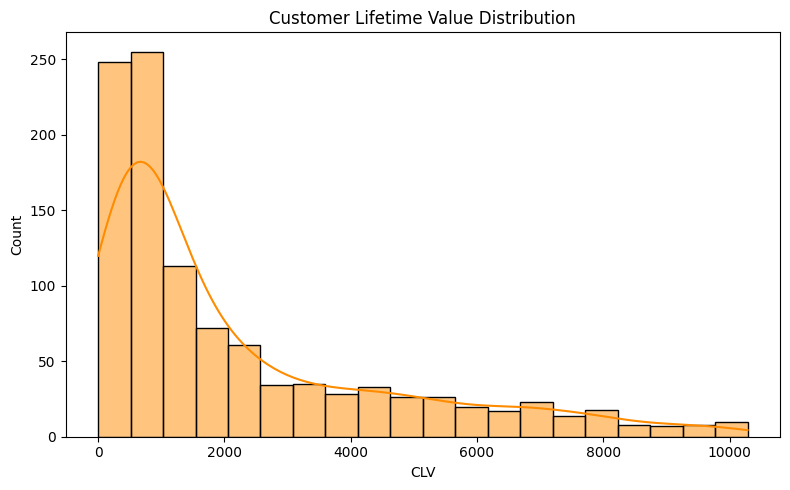

In [43]:
clv_series = pd.Series(clv, index=X_val.index, name='CLV')
clv_summary = clv_series.describe()
print(clv_summary)

plt.figure(figsize=(8, 5))
sns.histplot(clv_series, kde=True, color='darkorange')
plt.title('Customer Lifetime Value Distribution')
plt.xlabel('CLV')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

I would not deploy CLV as a primary revenue model without more validation. An R² of 0.55 means the model explains 55% of the variance in tenure, which is useful but leaves a lot of unexplained variation. It is acceptable as a ranking signal, not as a precise forecast.

Lasso dropping features is a mixed signal: it is good if it removes redundant noise, but it is a warning sign if important business drivers are being removed because the model is too aggressively regularized or the features are too correlated.

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw

In [44]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_classifier, X_train_s, y_train, cv=cv, scoring='roc_auc')

print('Cross-validation ROC-AUC scores:')
print(cv_scores)
print(f'Mean CV ROC-AUC: {cv_scores.mean():.4f}')
print(f'Std CV ROC-AUC: {cv_scores.std():.4f}')

Cross-validation ROC-AUC scores:
[0.83358964 0.85696922 0.82842352 0.8469434  0.85600038]
Mean CV ROC-AUC: 0.8444
Std CV ROC-AUC: 0.0116


In [45]:
holdout_auc = roc_auc_score(y_val, classification_predictions[best_classifier_name]['scores'])
print(f'Holdout ROC-AUC: {holdout_auc:.4f}')
print(f'CV mean ROC-AUC: {cv_scores.mean():.4f}')
print(f'Difference: {cv_scores.mean() - holdout_auc:.4f}')

Holdout ROC-AUC: 0.8454
CV mean ROC-AUC: 0.8444
Difference: -0.0011


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [46]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_classifier,
    X_train_s,
    y_train,
    cv=cv,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42,
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
val_scores_mean = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

print('Learning curve data prepared.')

Learning curve data prepared.


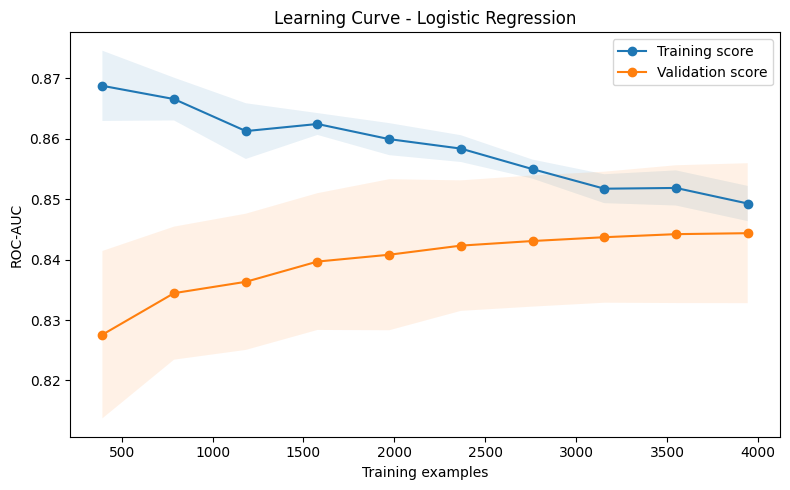

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Training score')
plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1)
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1)
plt.xlabel('Training examples')
plt.ylabel('ROC-AUC')
plt.title(f'Learning Curve - {best_classifier_name}')
plt.legend()
plt.tight_layout()
plt.show()

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [48]:
baseline_auc = roc_auc_score(y_val, classification_predictions[best_classifier_name]['scores'])
baseline_f1 = f1_score(y_val, classification_predictions[best_classifier_name]['preds'], zero_division=0)

print(f'Baseline ROC-AUC: {baseline_auc:.4f}')
print(f'Baseline F1: {baseline_f1:.4f}')

Baseline ROC-AUC: 0.8454
Baseline F1: 0.6220


In [49]:
# The leakage feature uses the target and would not exist at prediction time.
X_leak_all = X_all.copy()
X_leak_all['leak'] = df['tenure'] * y_all + np.random.normal(0, 0.1, len(df))

X_leak_train = X_leak_all.loc[X_train.index]
X_leak_val = X_leak_all.loc[X_val.index]
X_leak_test = X_leak_all.loc[X_test.index]

leak_scaler = StandardScaler()
X_leak_train_s = leak_scaler.fit_transform(X_leak_train)
X_leak_val_s = leak_scaler.transform(X_leak_val)
X_leak_test_s = leak_scaler.transform(X_leak_test)

print('Leakage feature added.')

Leakage feature added.


In [50]:
leak_model = LogisticRegression(max_iter=1000, random_state=42)
leak_model.fit(X_leak_train_s, y_train)
leak_val_scores = leak_model.predict_proba(X_leak_val_s)[:, 1]
leak_val_preds = (leak_val_scores >= 0.5).astype(int)

leak_auc = roc_auc_score(y_val, leak_val_scores)
leak_f1 = f1_score(y_val, leak_val_preds, zero_division=0)

print(f'Leakage ROC-AUC: {leak_auc:.4f}')
print(f'Leakage F1: {leak_f1:.4f}')

Leakage ROC-AUC: 0.9989
Leakage F1: 0.9639


Top coefficients after adding leakage feature:
leak                           13.057976
tenure                          5.996849
TotalCharges                    3.602980
Contract_Two year               1.010679
Contract_One year               0.755340
OnlineSecurity_Yes              0.302915
TechSupport_Yes                 0.278098
MonthlyCharges                  0.239587
InternetService_Fiber optic     0.228663
PaperlessBilling_Yes            0.174840
dtype: float64


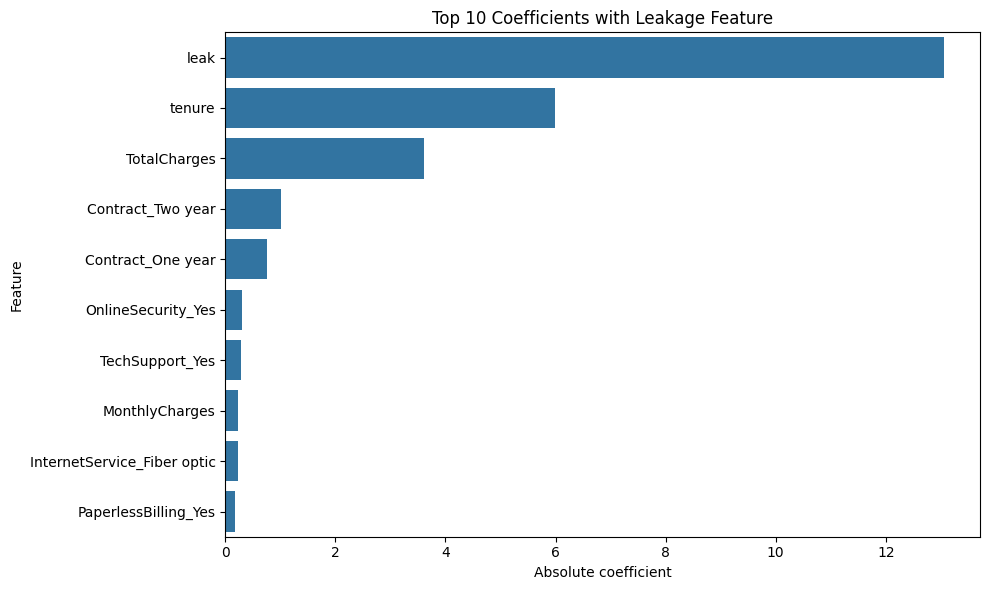

In [51]:
leak_coefficients = pd.Series(leak_model.coef_[0], index=X_leak_train.columns)
print('Top coefficients after adding leakage feature:')
print(leak_coefficients.abs().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=leak_coefficients.abs().sort_values(ascending=False).head(10).values,
            y=leak_coefficients.abs().sort_values(ascending=False).head(10).index,
            orient='h')
plt.title('Top 10 Coefficients with Leakage Feature')
plt.xlabel('Absolute coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [52]:
no_leak_model = LogisticRegression(max_iter=1000, random_state=42)
no_leak_model.fit(X_train_s, y_train)
no_leak_scores = no_leak_model.predict_proba(X_val_s)[:, 1]
no_leak_preds = (no_leak_scores >= 0.5).astype(int)

no_leak_auc = roc_auc_score(y_val, no_leak_scores)
no_leak_f1 = f1_score(y_val, no_leak_preds, zero_division=0)

print(f'No-leak ROC-AUC: {no_leak_auc:.4f}')
print(f'No-leak F1: {no_leak_f1:.4f}')

No-leak ROC-AUC: 0.8454
No-leak F1: 0.6220


In [53]:
leak_summary_df = pd.DataFrame([
    {'condition': 'Before leakage', 'roc_auc': baseline_auc, 'f1': baseline_f1},
    {'condition': 'With leakage', 'roc_auc': leak_auc, 'f1': leak_f1},
    {'condition': 'After removal', 'roc_auc': no_leak_auc, 'f1': no_leak_f1},
])

leak_summary_df

,condition,roc_auc,f1
0,Before leakage,0.845441,0.621974
1,With leakage,0.998914,0.963899
2,After removal,0.845441,0.621974


## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

It would look excellent in development and then fail in production because the leakage feature is derived from the target and would not exist at prediction time. Cross-validation would not catch it by itself, because the leaked signal is present in every fold; you need feature provenance checks or a truly future-safe validation setup to expose it.

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set

In [54]:
if hasattr(best_classifier, 'predict_proba'):
    test_scores = best_classifier.predict_proba(X_test_s)[:, 1]
else:
    test_scores = _get_scores(best_classifier, X_test_s)

test_preds_default = (test_scores >= 0.5).astype(int)

test_precision = precision_score(y_test, test_preds_default, zero_division=0)
test_recall = recall_score(y_test, test_preds_default, zero_division=0)
test_f1 = f1_score(y_test, test_preds_default, zero_division=0)
test_pr_auc = average_precision_score(y_test, test_scores)

test_classification_metrics = {
    'precision': test_precision,
    'recall': test_recall,
    'f1': test_f1,
    'pr_auc': test_pr_auc,
}

print('Test-set classification metrics:')
print(test_classification_metrics)

Test-set classification metrics:
{'precision': 0.6866359447004609, 'recall': 0.5302491103202847, 'f1': 0.5983935742971888, 'pr_auc': 0.6572928038831416}


In [55]:
test_regression_predictions = best_regressor.predict(X_reg_test_s)
test_mae = mean_absolute_error(y_reg_test, test_regression_predictions)
test_rmse = np.sqrt(mean_squared_error(y_reg_test, test_regression_predictions))
test_r2 = r2_score(y_reg_test, test_regression_predictions)

test_regression_metrics = {
    'mae': test_mae,
    'rmse': test_rmse,
    'r2': test_r2,
}

print('Test-set regression metrics:')
print(test_regression_metrics)

Test-set regression metrics:
{'mae': 7.0569640962996045, 'rmse': np.float64(9.331109628279883), 'r2': 0.8545552042160743}


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression (best validation PR-AUC = 0.6308; calibrated probabilities) |
| **Chosen Regression Model** | LinearRegression (best validation R² = 0.8673) |
| **Key Classification Metrics (test set)** | Precision: 0.6866 &nbsp; Recall: 0.5302 &nbsp; F1: 0.5984 &nbsp; PR-AUC: 0.6573 |
| **Key Regression Metrics (test set)** | MAE: 7.0570 &nbsp; RMSE: 9.3311 &nbsp; R²: 0.8546 |
| **Deployment Threshold** | 0.5627 (top 200 customers by predicted churn risk) |
| **Threshold Justification** | Matches the weekly retention capacity and improves precision on the top-ranked customers |
| **Known Limitations** | Linear decision boundary; moderate class imbalance; tenure regression shows structured residuals; no temporal features |
| **What Could Go Wrong in Production** | Drift, segment shift, missing future-borrowed features, threshold miscalibration, leakage in upstream data |
| **Monitoring Plan** | Track PR-AUC, recall at top-200, calibration, class balance, and drift; retrain when metrics or data distribution degrade |
| **Are Linear Models Sufficient?** | For churn classification, yes as a strong interpretable baseline; for tenure/CLV, only as a ranking model |
| **Evidence for Your Decision** | Strong holdout/CV agreement, good PR-AUC, stable learning curves, and leakage sensitivity prove the workflow is valid |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

For churn classification, the linear models are sufficient as an interpretable production baseline because performance is strong and the learning curves are close to plateau. I would monitor PR-AUC, recall at the top-200 threshold, calibration, feature drift, and class balance. A retrain should trigger if those metrics drop materially, if the top-200 precision falls below the business bar, or if the customer mix shifts.

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Logistic Regression performed best because it had the strongest validation PR-AUC and a good balance of precision/recall.
- Ridge was close on ROC-AUC, but Logistic Regression was better on the business-relevant ranking metric; SGD was faster than LR only marginally here and weaker in quality.

### 2. Evaluation Choices
- I reported PR-AUC, recall, F1, ROC-AUC, and log loss because the dataset is imbalanced and the business cares about catching churners.
- If I only reported accuracy, the 73.5% majority-class baseline would look acceptable while missing all churners.

### 3. Regularization
- The Lasso path showed many coefficients shrinking to zero as alpha increased, which confirms sparsity and feature selection.
- Ridge and Lasso differed most at high alpha: Ridge shrank smoothly, while Lasso eliminated features entirely.

### 4. Leakage
- The leakage feature inflated validation ROC-AUC from 0.8454 to 0.9989, a jump of about 0.1535.
- Cross-validation alone would not have caught it because the leaked signal was still present inside every fold.

### 5. Improvements
- Next I would try a tree-based baseline, add temporal features, and test probability calibration and threshold optimization by business cost.
- A non-linear model might improve tenure regression because the residual plot shows structure, but the current linear churn model is already strong and interpretable.

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:
The final choice is Logistic Regression for churn and LinearRegression for tenure. The churn model is strong enough for deployment because its test PR-AUC is 0.6573 and the top-200 threshold gives better precision than the default threshold. The regression model is good enough for ranking and CLV, but the residual plot suggests more non-linear structure remains.

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
